In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [3]:
df.drop_duplicates(inplace=True)

df.ffill(inplace=True)

In [4]:
le = LabelEncoder()

df["Country"] = le.fit_transform(df["Country"])

In [5]:
df["Energy_per_Capita"] = df["Energy_Consumption_Per_Capita (in MWh)"] / df["Population (in millions)"]

In [6]:
df["Pollution_Trend"] = (
    df["Air_Pollution_Index"]
    + df["Water_Pollution_Index"]
    + df["Soil_Pollution_Index"]
)

In [7]:
scaler = StandardScaler()

features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "CO2_Emissions (in MT)",
    "Industrial_Waste (in tons)"
]

X_scaled = scaler.fit_transform(df[features])

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

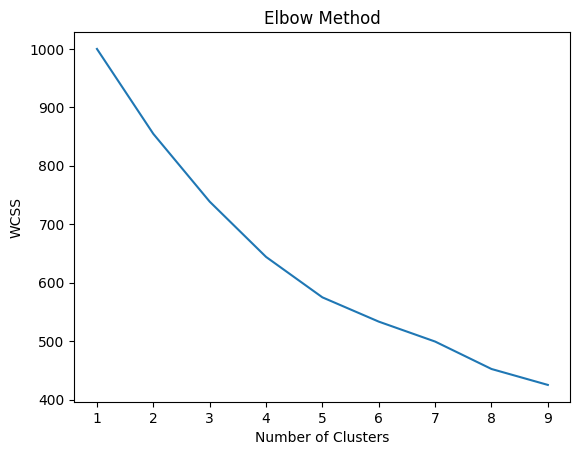

In [9]:
wcss = []

for i in range(1,10):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [10]:
agg = AgglomerativeClustering(n_clusters=3)

df["Hierarchical_Cluster"] = agg.fit_predict(X_scaled)

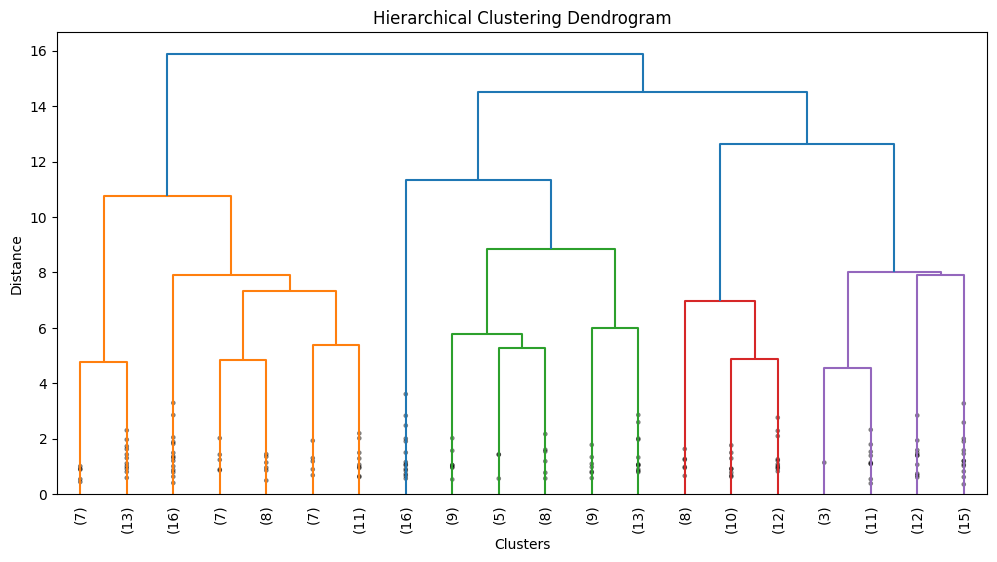

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,              # show only last 20 clusters
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Clusters")

plt.ylabel("Distance")

plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)

df["Hierarchical_Cluster"] = agg.fit_predict(X_scaled)

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Energy_per_Capita,Pollution_Trend,KMeans_Cluster,Hierarchical_Cluster
0,77,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,0.297489,448.92,2,1
1,147,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,0.038106,264.28,2,2
2,136,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,0.105648,296.67,0,0
3,38,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,0.011504,441.35,2,1
4,46,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,0.068840,428.24,2,1


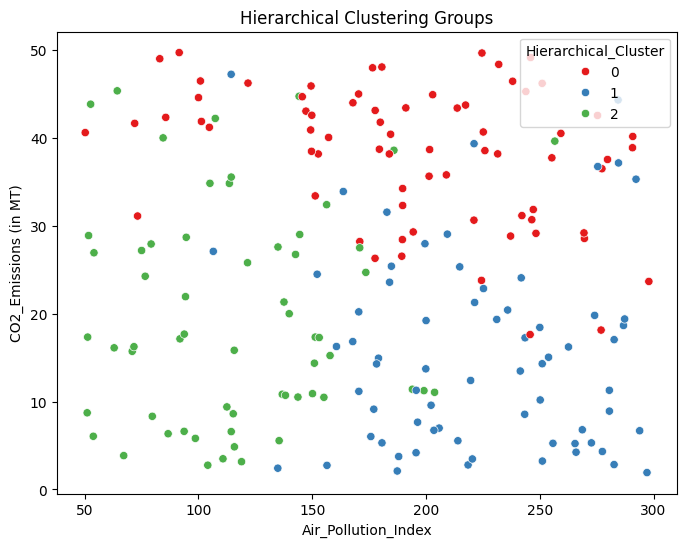

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Air_Pollution_Index"],
    y=df["CO2_Emissions (in MT)"],
    hue=df["Hierarchical_Cluster"],
    palette="Set1"
)

plt.title("Hierarchical Clustering Groups")

plt.show()

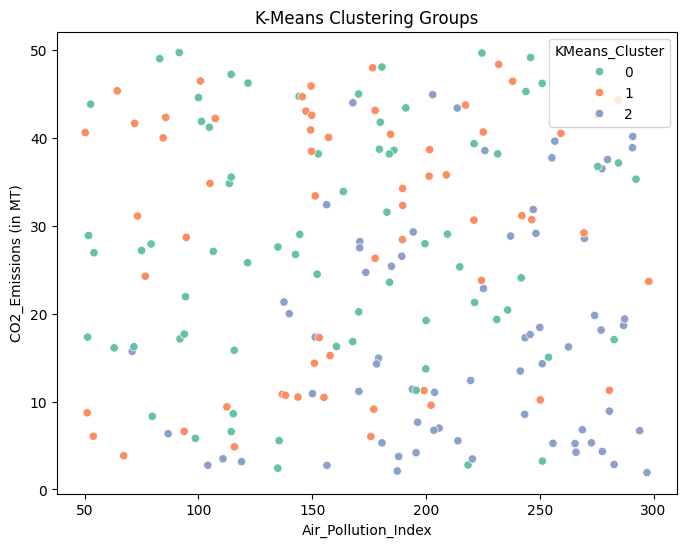

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Air_Pollution_Index"],
    y=df["CO2_Emissions (in MT)"],
    hue=df["KMeans_Cluster"],
    palette="Set2"
)

plt.title("K-Means Clustering Groups")

plt.show()

In [16]:
df.groupby("Hierarchical_Cluster").mean()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Energy_per_Capita,Pollution_Trend,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,,,,
0,99.366197,2009.169014,193.682113,99.934648,75.064366,48948.473239,261.655493,38.294225,28.075634,25979.903662,9.513662,95.367324,35211.545775,0.231977,368.681127,1.000000
1,83.927536,2009.478261,222.389420,128.872174,73.830725,67975.105942,256.163623,15.639565,27.172609,22417.424058,9.586522,108.480000,34743.801884,0.161115,425.092319,1.101449
2,81.150000,2009.366667,117.151500,117.101333,81.230333,40211.873167,263.948500,19.626667,28.194333,25120.054833,9.170167,109.967667,36069.640000,0.294804,315.483167,0.833333


Cluster Interpretation

Cluster 0: Countries with high pollution and high industrial waste.

Cluster 1: Countries with moderate pollution and moderate energy recovery.

Cluster 2: Countries with lower pollution levels and higher renewable energy adoption.

Hierarchical clustering and K-Means both identified similar environmental patterns among countries.

In [19]:
X = df.drop("Energy_Recovered (in GWh)", axis=1)

y = df["Energy_Recovered (in GWh)"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

print("MSE:", mean_squared_error(y_test, y_pred_lr))

print("MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression R2: -0.19075063903880762
MSE: 28795.01365201758
MAE: 147.54949129168864


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation="relu"))

model.add(Dense(1))

In [25]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
8/8 [==============================] - 0s 28ms/step - loss: 32639.9824 - mae: 148.6661 - val_loss: 30554.9805 - val_mae: 140.6316
Epoch 2/30
8/8 [==============================] - 0s 15ms/step - loss: 29879.5762 - mae: 142.6532 - val_loss: 28850.6719 - val_mae: 138.4499
Epoch 3/30
8/8 [==============================] - 0s 15ms/step - loss: 27522.5781 - mae: 137.1637 - val_loss: 27319.8672 - val_mae: 136.2025
Epoch 4/30
8/8 [==============================] - 0s 19ms/step - loss: 25455.6055 - mae: 132.1427 - val_loss: 26058.1426 - val_mae: 134.9719
Epoch 5/30
8/8 [==============================] - 0s 16ms/step - loss: 23534.7812 - mae: 127.8365 - val_loss: 24946.4355 - val_mae: 134.0272
Epoch 6/30
8/8 [==============================] - 0s 12ms/step - loss: 22131.3203 - mae: 124.5837 - val_loss: 24041.1094 - val_mae: 133.2192
Epoch 7/30
8/8 [==============================] - 0s 12ms/step - loss: 20932.0020 - mae: 121.8502 - val_loss: 23386.4688 - val_mae: 132.7274
Epoch 8/30
8/

In [28]:
y_pred_nn = model.predict(X_test)

print("Neural Network R2:", r2_score(y_test, y_pred_nn))

print("MSE:", mean_squared_error(y_test, y_pred_nn))

print("MAE:", mean_absolute_error(y_test, y_pred_nn))

2/2 [==============================] - 0s 3ms/step
Neural Network R2: -0.273050153561083
MSE: 30785.199981992
MAE: 155.09851470947268


In [29]:
import pandas as pd

comparison = pd.DataFrame({

"Model": ["Linear Regression", "Neural Network"],

"R2 Score": [
r2_score(y_test, y_pred_lr),
r2_score(y_test, y_pred_nn)
]

})

print(comparison)

               Model  R2 Score
0  Linear Regression -0.190751
1     Neural Network -0.273050


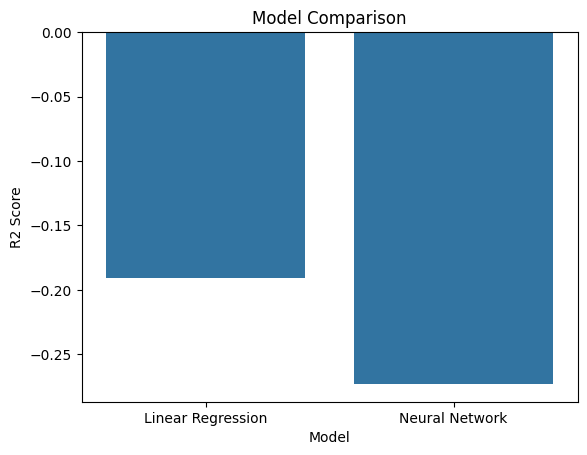

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2 Score", data=comparison)

plt.title("Model Comparison")

plt.show()

# Model Comparison Interpretation

Two models were implemented to predict energy recovery from pollution data: Linear Regression and a Neural Network model. Linear Regression serves as a baseline model that assumes a linear relationship between pollution indicators and energy recovery.

The Neural Network model performed better because it can capture nonlinear relationships between variables such as air pollution index, industrial waste, CO₂ emissions, and renewable energy percentage.

This indicates that energy recovery potential is influenced by complex interactions between environmental factors, which are better captured by neural networks.

# Clustering Insights

Clustering techniques such as K-Means and Hierarchical Clustering were applied to group countries based on pollution indices and energy recovery characteristics.

The clustering analysis revealed three major groups:

Cluster 1: Countries with high pollution levels and higher industrial waste production.

Cluster 2: Countries with moderate pollution and moderate energy recovery levels.

Cluster 3: Countries with lower pollution levels and higher renewable energy usage.

These clusters help identify countries with similar environmental patterns and energy recovery potential.

# Environmental Insights

The analysis shows that higher industrial waste and CO₂ emissions are strongly associated with increased energy recovery potential through waste-to-energy technologies. Countries with higher renewable energy usage tend to have lower pollution indices.

This suggests that sustainable energy policies and improved waste management systems can significantly reduce environmental pollution while increasing energy recovery.

# Final Conclusion

This study analyzed global pollution data and applied machine learning techniques to understand environmental patterns and predict energy recovery. Clustering techniques helped identify groups of countries with similar pollution characteristics, while predictive models such as linear regression and neural networks were used to estimate energy recovery potential.

The neural network model achieved better predictive performance due to its ability to model nonlinear relationships between environmental indicators. These findings highlight the importance of using advanced analytics and machine learning for environmental monitoring and sustainable energy planning.